In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import pathlib
import utils.make_paths_absolute

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)

In [5]:
energy_files = list(pathlib.Path("input/energy_mappings/alt_energies").rglob("*.pkl"))
file_to_qubit_count_mapping = {}
for file in energy_files:
    file_stem = str(file.stem)
    str_qubit_count = file.as_posix().split("/")[-2]
    try:
        qubit_count = int(str_qubit_count)
        file_to_qubit_count_mapping[file_stem] = qubit_count
    except ValueError:
        print(f"Warning: Could not convert '{str_qubit_count}' to an integer for file {file_stem}. Skipping this file.")


def get_files_by_folders(results_folders):
    result_paths = []
    for results_folder in results_folders:
        paths = list(pathlib.Path(f"{results_folder}").rglob("*.npz"))
        result_paths.extend(paths)

    return {path.as_posix().split("/")[-1].split(".")[0]: {"path": path} for path in result_paths}


def generate_df_from_files(result_files, file_to_qubit_count_mapping, target_confidence=0.9999):
    data_keys = ["cost_history", "target_probs", "target_indices", "best_target_index", "conformation_map"]

    for name, data in result_files.items():
        with open(data["path"], 'rb') as f:
            saved_results = np.load(f, allow_pickle=True)
            result_files[name]["data"] = {key: saved_results[key] for key in data_keys}

        result_files[name]["protein"] = name.split("_")[0]
        result_files[name]["start_residue"] = int(name.split("_")[1])
        result_files[name]["end_residue"] = int(name.split("_")[2])
        result_files[name]["rotamer_count"] = int(name.split("_")[3])
        result_files[name]["qaoa_layers"] = int(name.split("_")[4])

        result_files[name]["subsection"] = f"{result_files[name]['start_residue']}-{result_files[name]['end_residue']}"
        result_files[name]["subsection_length"] = result_files[name]["end_residue"] - result_files[name][
            "start_residue"] + 1

        name_without_layers = "_".join(name.split("_")[:-2])
        if name_without_layers in file_to_qubit_count_mapping:
            result_files[name]["num_qubits"] = file_to_qubit_count_mapping[name_without_layers]
        else:
            print(f"Warning: No qubit mapping found for {name_without_layers}. Setting num_qubits to None.")
            result_files[name]["num_qubits"] = None

    target_probs_records = []
    for name, data in result_files.items():
        # if not name.startswith("5PTI_18_22"): continue

        target_probs = result_files[name]["data"]['target_probs']
        # print("Shape of target_probs:", target_probs.shape)  # Should be (30, 16)

        # Sum across the 16 conformations for each seed
        summed_probs = target_probs.sum(axis=1)  # Shape becomes (30,)
        # print("Shape after summing across conformations:", summed_probs.shape)

        # Create a record for each seed with its summed probability
        for seed_idx, summed_prob in enumerate(summed_probs):
            if int(summed_prob) == 1:
                shots_for_target_prob = 1
            else:
                shots_for_target_prob = np.ceil(np.log(1 - target_confidence) / np.log(1 - summed_prob))
            record = {
                'protein': result_files[name]['protein'],
                'subsection': result_files[name]['subsection'],
                'subsection_length': result_files[name]['subsection_length'],
                'rotamer_count': result_files[name]['rotamer_count'],
                'qaoa_layers': result_files[name]['qaoa_layers'],
                'num_qubits': result_files[name]['num_qubits'],
                'seed': seed_idx,
                'target_prob': summed_prob,  # This is now the sum across all 16 conformations
                'shots_for_target_prob': shots_for_target_prob
            }
            target_probs_records.append(record)

    # Create dataframe from records
    return pd.DataFrame(target_probs_records)

In [6]:
colab_files = get_files_by_folders(["outputs/runs_before_round_robin_rotamers_param/QAOA_Results_Backup 2",
                                    "outputs/runs_before_round_robin_rotamers_param/QAOA_Results_Backup_3"])
colab_df = generate_df_from_files(colab_files, file_to_qubit_count_mapping)
colab_df = colab_df[colab_df['num_qubits'] >= 14]

local_files = get_files_by_folders(["outputs/runs_before_round_robin_rotamers_param/prev_in_qaoa/qaoa_runs_5-14_batch1",
                                    'outputs/runs_before_round_robin_rotamers_param/prev_in_qaoa/qaoa_runs_5-14_batch2'])
local_df = generate_df_from_files(local_files, file_to_qubit_count_mapping)
local_df = local_df[local_df['num_qubits'] <= 14]

combined_df = pd.concat([colab_df, local_df], ignore_index=True)

twelve_layer_df = combined_df[combined_df['qaoa_layers'] == 12]


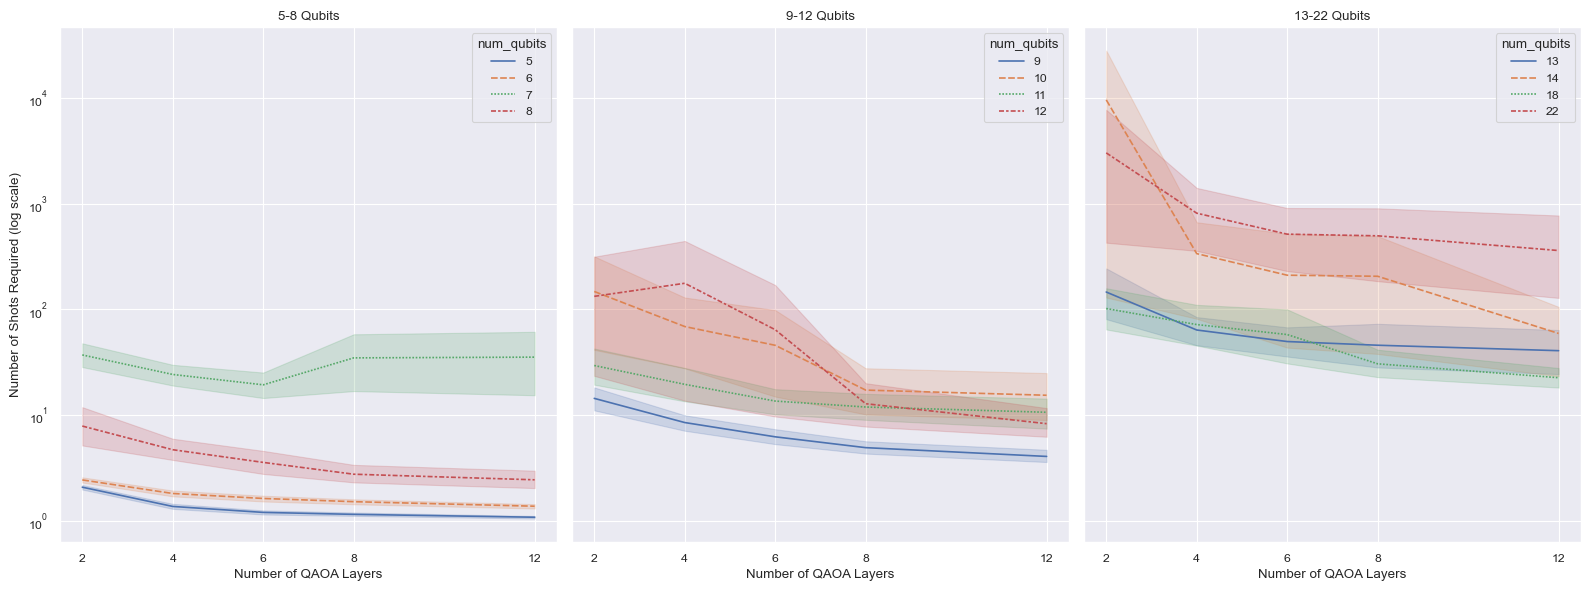

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

data_5_8 = combined_df[(combined_df['num_qubits'] >= 5) & (combined_df['num_qubits'] <= 8)]
data_9_12 = combined_df[(combined_df['num_qubits'] >= 9) & (combined_df['num_qubits'] <= 12)]
data_13_22 = combined_df[(combined_df['num_qubits'] >= 13) & (combined_df['num_qubits'] <= 22)]

sns.lineplot(data=data_5_8,
             x="qaoa_layers", y="shots_for_target_prob",
             hue='num_qubits', style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep',
                                       n_colors=data_5_8['num_qubits'].nunique()),
             ax=ax1)
ax1.set_xticks([2, 4, 6, 8, 12])
ax1.set_title("5-8 Qubits")
ax1.set_ylabel("Number of Shots Required (log scale)")
ax1.set_xlabel("Number of QAOA Layers")

sns.lineplot(data=data_9_12,
             x="qaoa_layers", y="shots_for_target_prob",
             hue='num_qubits', style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep',
                                       n_colors=data_9_12['num_qubits'].nunique()),
             ax=ax2)
ax2.set_xticks([2, 4, 6, 8, 12])
ax2.set_title("9-12 Qubits")
ax2.set_ylabel("Number of Shots Required (log scale)")
ax2.set_xlabel("Number of QAOA Layers")

sns.lineplot(data=data_13_22,
             x="qaoa_layers", y="shots_for_target_prob",
             hue='num_qubits', style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep',
                                       n_colors=data_13_22['num_qubits'].nunique()),
             ax=ax3)

ax3.set_xticks([2, 4, 6, 8, 12])
ax3.set_title("13-22 Qubits")
ax3.set_ylabel("Number of Shots Required (log scale)")
ax3.set_xlabel("Number of QAOA Layers")

# Share the same y-axis limits if desired
ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')


plt.tight_layout()
plt.savefig(f"plots/combined_local_colab_shots_split.svg", dpi=300, bbox_inches='tight')

Fitted parameters: a=3.46e-01, b=3.14e-01


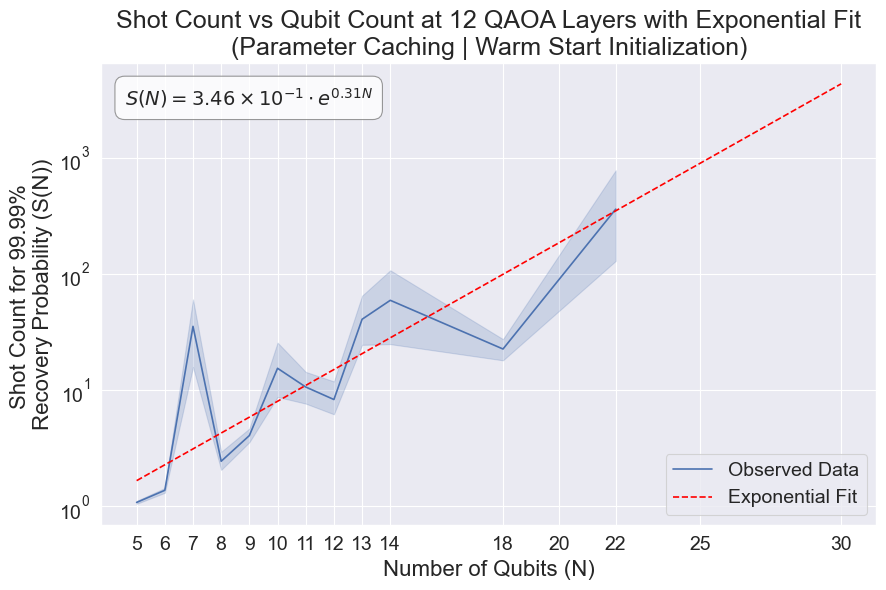

In [10]:
# Extrapolate the 12-layer curve to estimate shots for 30 qubits
from scipy.optimize import curve_fit
def exponential_model(x, a, b):
    return a * np.exp(b * x)

x_data = twelve_layer_df['num_qubits']
y_data = twelve_layer_df['shots_for_target_prob']

fit_result = curve_fit(exponential_model, x_data, y_data, p0=(1e3, 0.1))
popt = fit_result[0]
a, b = popt
print(f"Fitted parameters: a={a:.2e}, b={b:.2e}")
x_extrapolate = np.arange(5, 31)
y_extrapolate = exponential_model(x_extrapolate, a, b)

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=twelve_layer_df,
             x="num_qubits", y="shots_for_target_prob",
             markers=True,
             ax=ax, label='Observed Data')
ax.plot(x_extrapolate, y_extrapolate, label='Exponential Fit', linestyle='--', color='red')

a_str = f"{a:.2e}"

# 2. Split it into the base number and the exponent
base, exponent = a_str.split('e')

# 3. Create a LaTeX formatted string (int(exponent) removes the leading zero)
a_latex = f"{base} \\times 10^{{{int(exponent)}}}"

# 4. Insert the clean scientific notation into the final equation
equation_text = f"$S(N) = {a_latex} \\cdot e^{{{b:.2f}N}}$"
# Place the text box in the upper left corner
ax.text(0.03, 0.95, equation_text, transform=ax.transAxes, fontsize=14,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

ax.set_title("Shot Count vs Qubit Count at 12 QAOA Layers with Exponential Fit\n(Parameter Caching | Warm Start Initialization)", fontsize=18)
ax.set_xlabel("Number of Qubits (N)", fontsize=16)
ax.set_ylabel("Shot Count for 99.99% \nRecovery Probability (S(N))", fontsize=16)
ax.set_yscale('log')

xticks = sorted(twelve_layer_df['num_qubits'].unique())
xticks.extend([20, 25, 30])
ax.set_xticks(sorted(xticks))

ax.legend(fontsize=14)
ax.tick_params(axis="both", labelsize=14)

plt.savefig(f"plots/combined_local_colab_shots_by_qubits_at_last_layer_with_fit.svg", dpi=300, bbox_inches='tight')
plt.show()

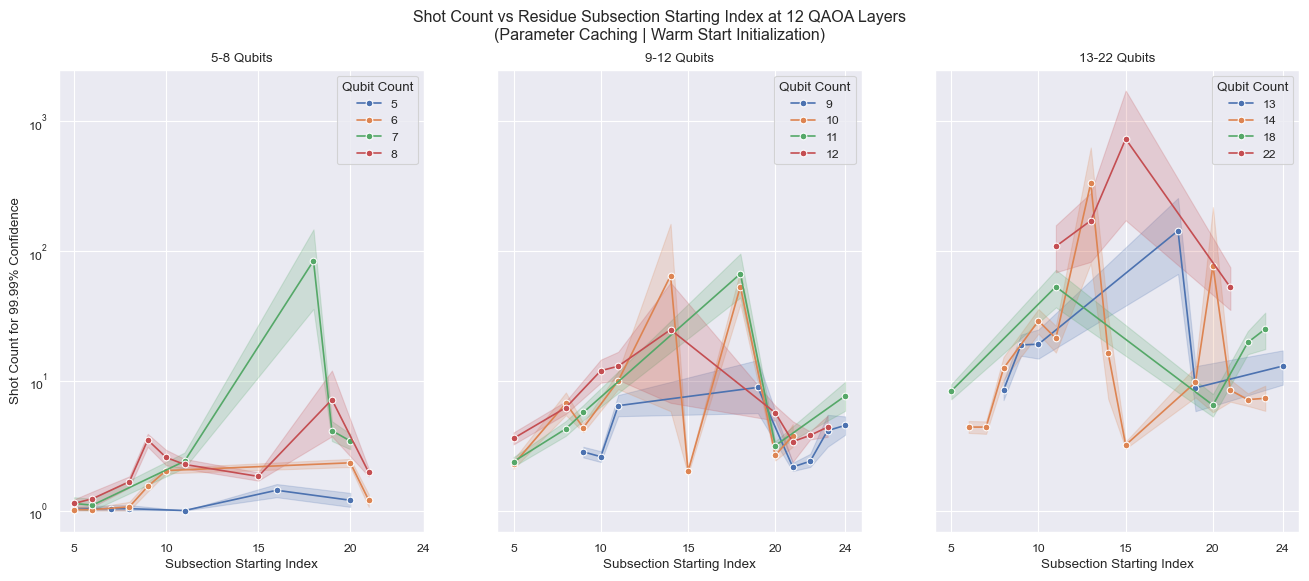

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

combined_df = pd.concat([colab_df, local_df], ignore_index=True)

twelve_layer_df = combined_df[combined_df['qaoa_layers'] == 12]
plot_df = twelve_layer_df.dropna(subset=["subsection"]).copy()

# 2. Extract the starting index from the 'subsection' column
# This splits the string "18-24" by "-" and takes the first element ("18"), converting it to an integer
plot_df["start_index"] = plot_df["subsection"].apply(lambda s: int(str(s).split("-")[0]))


data_5_8 = plot_df[(plot_df['num_qubits'] >= 5) & (plot_df['num_qubits'] <= 8)]
data_9_12 = plot_df[(plot_df['num_qubits'] >= 9) & (plot_df['num_qubits'] <= 12)]
data_13_22 = plot_df[(plot_df['num_qubits'] >= 13) & (plot_df['num_qubits'] <= 22)]

x_ticks_order = sorted(plot_df["start_index"].unique())
# instead of using all start indices as x-ticks, we can use a subset for better readability, e.g., every 5th index
highest_idx = max(x_ticks_order)
x_ticks_order = [idx for idx in x_ticks_order if idx % 5 == 0 or idx == highest_idx]  # Keep every 5th index and the highest index

sns.lineplot(data=data_5_8,
             x="start_index", y="shots_for_target_prob",
             hue='num_qubits',
    marker="o",
             palette=sns.color_palette('deep',
                                       n_colors=data_5_8['num_qubits'].nunique()),
             ax=ax1)
ax1.set_xticks(x_ticks_order)
ax1.set_title("5-8 Qubits")
ax1.set_ylabel("Shot Count for 99.99% Confidence")
ax1.set_xlabel("Subsection Starting Index")

sns.lineplot(data=data_9_12,
             x="start_index", y="shots_for_target_prob",
             hue='num_qubits',
    marker="o",
             palette=sns.color_palette('deep',
                                       n_colors=data_9_12['num_qubits'].nunique()),
             ax=ax2)
ax2.set_xticks(x_ticks_order)
ax2.set_title("9-12 Qubits")
ax2.set_ylabel("Shot Count for 99.99% Confidence")
ax2.set_xlabel("Subsection Starting Index")

sns.lineplot(data=data_13_22,
             x="start_index", y="shots_for_target_prob",
             hue='num_qubits',
    marker="o",
             palette=sns.color_palette('deep',
                                       n_colors=data_13_22['num_qubits'].nunique()),
             ax=ax3)

ax3.set_xticks(x_ticks_order)
ax3.set_title("13-22 Qubits")
ax3.set_ylabel("Shot Count for 99.99% Confidence")
ax3.set_xlabel("Subsection Starting Index")


# Share the same y-axis limits if desired
ax1.set_yscale('log')
ax2.set_yscale('log')
ax3.set_yscale('log')

ax1.legend(title="Qubit Count")
ax2.legend(title="Qubit Count")
ax3.legend(title="Qubit Count")

fig.suptitle("Shot Count vs Residue Subsection Starting Index at 12 QAOA Layers\n(Parameter Caching | Warm Start Initialization)")

# 6. Save and display
plt.savefig("plots/shot_limit_by_subsection_by_qubits.svg", dpi=300, bbox_inches='tight')
plt.show()